In [1]:
from torchvision.datasets import CelebA
from torchvision import transforms

from torchvision.models import ResNet18_Weights

import torchvision
from torch import nn
from torch.nn import functional as F
from torch.utils.data import TensorDataset, DataLoader
from torch.utils.data import random_split


from torchmetrics.classification import BinaryAUROC, Accuracy

import torch
from pytorch_lightning.loggers import WandbLogger

import numpy as np 

import wandb

from datetime import datetime
from tqdm.notebook import tqdm

from collections import OrderedDict

from xaikd import utils, attributors, models

import pandas as pd
from xaikd.bases import PRCAReconGreedy

from matplotlib import pyplot as plt 

import numpy.typing as npt

import os

In [2]:
DATA_ROOT = "../../datasets"

WANDB_PROJECT = "xaikd-training-teacher-models"
WANDB_GROUP = "celeba"

NUM_WORKERS = 16
BATCH_SIZE = 64
NUM_ATTRIBUTES = 40

TRAINING_SIZE = 0.01

SEED = 1

DEVICE = "cuda"

ARCH = "resnet18"

RUN_ID = "n8r0q2vb"
# RUN_ID = "6oj5aaxl" # imagenet pretrained
# RUN_ID = "dskgwbyk" # fc.bias= False


# WANDB_PROJECT = "kitchen-sink"
# RUN_ID = "jtp7uv29"

In [3]:
TRANSFORMATION_DEFAULT = ResNet18_Weights.IMAGENET1K_V1.transforms()

In [4]:
TRANSFORMATION_DEFAULT.mean, TRANSFORMATION_DEFAULT.std

([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])

In [5]:
ds_train = CelebA(
    root=DATA_ROOT, split="train", target_type="attr",
    transform=TRANSFORMATION_DEFAULT
)

trng = torch.Generator()
trng.manual_seed(1)
ds_train, _ = random_split(ds_train, [TRAINING_SIZE, 1-TRAINING_SIZE], generator=trng)

dl_train = DataLoader(
    ds_train,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,    
    shuffle=False,
)

In [6]:
ds_val = CelebA(
    root=DATA_ROOT, split="valid", target_type="attr",
    transform=TRANSFORMATION_DEFAULT
)

ds_val, _ = random_split(ds_val, [TRAINING_SIZE, 1-TRAINING_SIZE], generator=trng)

dl_val = DataLoader(
    ds_val,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,    
    shuffle=False,
)

In [7]:
class MultiTaskHead(nn.Module):
    def __init__(self, in_dims, num_tasks, out_per_task):
        super().__init__()
        
        arr_heads = []
        for tix in range(num_tasks):
            head = nn.Linear(in_features=in_dims, out_features=out_per_task)
            arr_heads.append(head)
        self.arr_heads = nn.ModuleList(arr_heads)
        self.task_id = None

    def forward(self, x):
        if self.task_id is not None:
            return self.arr_heads[self.task_id](x)
    
        arr_out = []

        
        for head in self.arr_heads:
            headout = head(x)
            b, d = headout.shape
            arr_out.append(headout.reshape(b, 1, d))

        out = torch.cat(arr_out, dim=1)
        return out
        
def get_state_dict(run_id):
    agent = wandb.Api()

    artifact: wandb.Artifact = agent.artifact(
        f"{WANDB_PROJECT}/model-{RUN_ID}:latest"
    )

    artifact_dir = artifact.download(root="/tmp")

    ckpt = torch.load(
        f"{artifact_dir}/model.ckpt",
        map_location=torch.device("cpu"),
        weights_only=False,
    )

    state_dict = ckpt["state_dict"]

    new_dict = OrderedDict()
    for k, v in state_dict.items():
        new_k = k.replace("encoder.", "")
        new_dict[new_k] = v
        
    return new_dict

def get_model(arch):

    state_dict = get_state_dict(RUN_ID)
    
    if arch == "resnet18":
        model = torchvision.models.resnet18(weights=None, num_classes=NUM_ATTRIBUTES)
        # out_dims, in_dims = model.fc.weight.shape
        
        # model.fc = MultiTaskHead(in_dims, NUM_ATTRIBUTES, 2)
    
    model.load_state_dict(state_dict)

    model.eval()
    model.to(DEVICE)
    
    return model
    
model = get_model(ARCH);

wandb: Downloading large artifact model-n8r0q2vb:latest, 128.27MB. 1 files... 
wandb:   1 of 1 files downloaded.  
Done. 0:0:5.9


In [8]:
def estimate_task_performance(model, dl, task_id, verbose=False):

    # metric = Accuracy(task="multiclass", num_classes=2)
    metric = BinaryAUROC(thresholds=20)
    model.to(DEVICE)

    for x, y in tqdm(dl, disable=not verbose):
        x = x.to(DEVICE)
        task_logit = model(x)[:, task_id].cpu()
        task_target = y[:, task_id]
        metric.update(task_logit, task_target)

    metric = float(metric.compute())
    metric = np.max([metric, 1-metric])
    return metric

# cross-check with wandb that we have correct results
estimate_task_performance(model, dl_val, task_id=0, verbose=True)

  0%|          | 0/4 [00:00<?, ?it/s]

0.9554470181465149

  0%|          | 0/26 [00:00<?, ?it/s]

  0%|          | 0/26 [00:00<?, ?it/s]

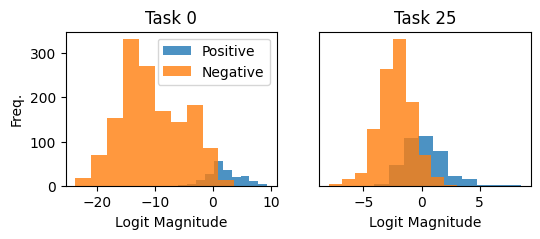

In [18]:
def viz_task_logit_distribution(arr_task_ids):

    ncols = 2
    plt.figure(figsize=(3*ncols, 2))

    for tix, task_id in enumerate(arr_task_ids):
        plt.subplot(1, ncols, tix + 1)

        plt.title(f"Task {task_id}")

        arr_target = []
        arr_logit = []
        for x, y in tqdm(dl_train):
            x = x.to(DEVICE)
            
            task_logit = model(x)[:, task_id].detach().cpu().numpy().tolist()
            task_target = y[:, task_id].numpy().tolist()

            arr_logit.extend(task_logit)
            arr_target.extend(task_target)

        arr_target = np.array(arr_target)
        arr_logit = np.array(arr_logit)

        vmin = np.min(arr_logit)
        vmax = np.max(arr_logit)
        bins = np.linspace(vmin, vmax, 100)
        plt.hist(
            arr_logit[arr_target == 1],
            label="Positive",
            alpha=0.8
        )
        plt.hist(
            arr_logit[arr_target == 0],
            label="Negative",
            alpha=0.8
        )

        if tix == 0:
            plt.ylabel("Freq.")
        
            plt.legend()
        else:
            plt.yticks([])

        plt.xlabel("Logit Magnitude")
    
viz_task_logit_distribution(arr_task_ids=[0, 25])

# Extract Activation and Context Vectors for Task

In [21]:
class VoidAttributor:

    def __enter__(self, **kwargs):
        pass

    def __exit__(self, type, value, tb):
        pass

def compute_logodd_winning(logits):

    return torch.sign(logits).detach() * logits

def compute_logits(logits):

    return logits

class OutputQuantity:
    def __call__(self, logits, target_logits):
        raise NotImplementedError()
    def __str__(self):
        return self.__class__.__name__
        
class LogOddWinningClass(OutputQuantity):
    def __call__(self, logits, targets):
        return torch.sign(logits).detach() * logits


class LogOddSquared(OutputQuantity):
    def __call__(self, logits, targets):
        return (torch.sign(logits).detach() * logits).pow(2)
        
class LogOddPositiveClass(OutputQuantity):
    def __call__(self, logits, targets):
        return logits


class LogOddTargetClass(OutputQuantity):
    def __call__(self, logits, targets):
        return torch.sign(2*targets-1) * logits
        

class BinaryCrossEntropyWinning(OutputQuantity):
    def __call__(self, logits, targets):
        winning_target = torch.sign(logits).detach()
        return - F.binary_cross_entropy_with_logits(logits, winning_target)

In [25]:
OUTPUT_QUANTITY = LogOddWinningClass()

def extract_activation_context_for_task(
    model: nn.Module,
    layer: str,
    data_loader: DataLoader,
    task_id: int,
    use_lrp=False,
    seed=1,
    device=DEVICE,
    number_of_selected_spatial_locations=20,
    strict_mode=False,
    verbose=False
):

    arr_logodds = []
    arr_act = []
    arr_ctx = []
    output_quantity = OUTPUT_QUANTITY

    rng = np.random.default_rng(seed=1)

    task_query_vector = F.one_hot(torch.tensor(task_id), num_classes=NUM_ATTRIBUTES).to(DEVICE)
    try:
        model.fc.task_id = task_id
        
        module, hook = utils.interceptor.attach_hook_intercept_layer_output(
            model, layer, should_retain_grad=True, detach_output=False
        )

        attributor = attributors.make_attributor_for(
            model,
            (
                TRANSFORMATION_DEFAULT.mean, TRANSFORMATION_DEFAULT.std
            )
        ) if use_lrp else VoidAttributor()
        
        with attributor:
            for batch in tqdm(data_loader, desc=f"[layer={layer}; task_id={task_id} use_lrp={use_lrp}] extract act ctx (wrt {output_quantity})"):
                x, y = batch
                x = x.to(device)

                if use_lrp:
                    raise NotImplementedError("obsolete")
                    _ = attributor.forward(x, lambda logits: logits * task_query_vector)
    
                    act = utils.interceptor.get_output(module)
    
                    assert act.grad is not None
                    rel = act.grad
    
    
                    ctx = torch.where(act.abs() > 0, rel / act, 0)
                    assert torch.isfinite(ctx).all()
                    
                    if strict_mode:
                        np.testing.assert_allclose(
                            (act * ctx).detach().cpu().numpy(),
                            rel.detach().cpu().numpy(),
                            atol=1e-6,
                        )
                else:
                    logits = model(x)
                    task_logit = logits[:, task_id]
                    task_target = y[:, task_id].to(device)
                    
                    quantities = output_quantity(task_logit, task_target)
                    # quantities = compute_logits(task_logit)
                    
                    (quantities).sum().backward()
                    act = utils.interceptor.get_output(module)
    
                    assert act.grad is not None
                    ctx = act.grad
                
                output_dimensions = act.shape[1:]


                assert ctx.shape == act.shape

                act = act.detach().cpu().numpy()
                ctx = ctx.detach().cpu().numpy()

                selected_act, selected_ctx = utils.subsample_tensors(
                    act,
                    ctx,
                    num_locations=number_of_selected_spatial_locations,
                    rng=rng,
                )
                
                arr_act.append(selected_act)
                arr_ctx.append(selected_ctx)
                arr_logodds.append(quantities.detach().cpu().numpy())

    finally:
        hook.remove()
        model.fc.task_id = None

    print(f"{layer}: output-dims={output_dimensions}")

    arr_act = np.vstack(arr_act)
    arr_ctx = np.vstack(arr_ctx)
    # print("arr_act.shape", arr_act.shape)
    arr_logodds = np.hstack(arr_logodds)
    # print("arr_logodd.shape", arr_logodds.shape)

    return arr_logodds, arr_act, arr_ctx

def ano():

    for use_lrp in [False]:

        extract_activation_context_for_task(
            model, 
            "layer3",
            dl_train,
            task_id=25,
            use_lrp=use_lrp
        )
        
        print(f"Sanity check: [use_lrp={use_lrp}; passed!")
ano()

[layer=layer3; task_id=25 use_lrp=False] extract act ctx (wrt LogOddWinningClass):   0%|          | 0/26 [00:0…

layer3: output-dims=torch.Size([256, 14, 14])
Sanity check: [use_lrp=False; passed!


# Constructing Basis 

In [26]:
def _solve_eigvecs(cov, sort_func=lambda x: x):
    eigvals, eigvecs = np.linalg.eigh(cov)

    assert len(eigvals.shape) == 1

    indices = np.argsort(-sort_func(eigvals))
    eigvals = eigvals[indices]
    eigvecs = eigvecs[:, indices]

    return eigvecs, eigvals

In [28]:
class BasisInterface:
    def get_Uk(self, k: int) -> npt.NDArray:
        raise NotImplementedError()   

class PCA(BasisInterface):
    def __init__(self, arr_logodds, arr_act, arr_ctx, layer=None, task_id=None):
        cov = arr_act.T @ arr_act
        self.U, self.eigvals = _solve_eigvecs(cov)
        
    def get_Uk(self, k: int):
        return self.U[:, :k]

class GradPCA(BasisInterface):
    def __init__(self, arr_logodds, arr_act, arr_ctx, layer=None, task_id=None):
        cov = arr_ctx.T @ arr_ctx
        self.U, self.eigvals = _solve_eigvecs(cov)
        
    def get_Uk(self, k: int):
        return self.U[:, :k]

## PRCA Variants

In [33]:
class PRCA(BasisInterface):
    def __init__(self, arr_logodds, arr_act, arr_ctx, layer=None, task_id=None):
        cov = arr_act.T @ arr_ctx + arr_ctx.T @ arr_act
        self.U, _ = _solve_eigvecs(cov)
        
    def get_Uk(self, k: int):
        return self.U[:, :k]

class PRCASortAbs(BasisInterface):
    def __init__(self, arr_logodds, arr_act, arr_ctx, layer=None, task_id=None):
        cov = arr_act.T @ arr_ctx + arr_ctx.T @ arr_act
        self.U, _ = _solve_eigvecs(cov, sort_func=np.abs)
        
    def get_Uk(self, k: int):
        return self.U[:, :k]

class PRCAPosDef(BasisInterface):
    def __init__(self, arr_logodds, arr_act, arr_ctx, layer=None, task_id=None):

        pca = PCA(arr_logodds=arr_logodds, arr_act=arr_act, arr_ctx=arr_ctx)
        gradpca = GradPCA(arr_logodds=arr_logodds, arr_act=arr_act, arr_ctx=arr_ctx)
        
        arr_act = arr_act / ( np.sum(pca.eigvals) ** 0.5)
        arr_ctx = arr_ctx / ( np.sum(gradpca.eigvals) ** 0.5)


        cov_a = 2*(arr_act.T @ arr_act)
        cov_c = 2*(arr_ctx.T @ arr_ctx)
        cov_ac = arr_act.T @ arr_ctx + arr_ctx.T @ arr_act
        
        cov = cov_ac + cov_a + cov_c
        
        self.U, self.eigvals = _solve_eigvecs(cov)
        
    def get_Uk(self, k: int):
        return self.U[:, :k]

# Estimating AUROCs

In [35]:
def construct_fh(Uk):
    def fh(mod, inp, outp):
        return F.conv2d(
            outp,
            (Uk@Uk.T).unsqueeze(2).unsqueeze(3)
        )
    return fh

def compute_task_aurocs_at_k(
    model, layer, task_id, 
    arr_ks,
    arr_basis_names=[
        PCA
    ],
):
    arr_logodds, arr_act, arr_ctx = extract_activation_context_for_task(
        model=model, 
        layer=layer, 
        data_loader=dl_train, 
        task_id=task_id,
    )
    
    rel = (arr_act  * arr_ctx).sum(axis=1)

    module = getattr(model, layer)


    arr_dfs = []
    for basis_class in arr_basis_names:
        arr_stat_rows = []

        basis: BasisInterface = basis_class(
            arr_logodds=arr_logodds,
            arr_act=arr_act, 
            arr_ctx=arr_ctx,
            layer=layer,
            task_id=task_id
        )
        basis_name = basis_class.__name__

        for k in tqdm(
            arr_ks,
            desc=f"[{basis_name:<20s}] Estimating Performance"
        ):
        
            if ("-k" in basis_name) and not f"{k}" == basis_name.split("k")[1]:
                continue

            Uk = basis.get_Uk(k=k)

            row = dict(
                
                task_id=task_id,
                layer=layer,
                output_quantity=f"{OUTPUT_QUANTITY.__class__.__name__}",
                k=k,
                basis_name=basis_name,
            )

            Uk = torch.from_numpy(Uk).to(DEVICE)

            try:
                hook = module.register_forward_hook(construct_fh(Uk))
                
                for label, dl in [
                    # ("train", dl_train),
                    ("val", dl_val)
                ]:
                    row[f"{label}_auroc"] = estimate_task_performance(model, dl, task_id)
                
            finally:
                hook.remove()

            arr_stat_rows.append(row)
            
     
        df = pd.DataFrame(arr_stat_rows)
        # df.to_csv(
        #     f"{output_path}/{basis_name}.csv",
        #     index=False
        # )

        arr_dfs.append(df)

    df = pd.concat(arr_dfs).sort_values(by=["k", f"val_auroc"], ascending=[True, False])
    return df

compute_task_aurocs_at_k(
    model, layer="layer3", task_id=0, 
    arr_basis_names=[
        PCA,
        GradPCA,
        
        PRCA,     
        PRCASortAbs,
        PRCAPosDef,
    ],
    arr_ks=[5, 10, 20, 30, 256],
)

[layer=layer3; task_id=0 use_lrp=False] extract act ctx (wrt LogOddWinningClass):   0%|          | 0/26 [00:00…

layer3: output-dims=torch.Size([256, 14, 14])


[PCA                 ] Estimating Performance:   0%|          | 0/5 [00:00<?, ?it/s]

[GradPCA             ] Estimating Performance:   0%|          | 0/5 [00:00<?, ?it/s]

[PRCA                ] Estimating Performance:   0%|          | 0/5 [00:00<?, ?it/s]

[PRCASortAbs         ] Estimating Performance:   0%|          | 0/5 [00:00<?, ?it/s]

[PRCAPosDef          ] Estimating Performance:   0%|          | 0/5 [00:00<?, ?it/s]

,task_id,layer,output_quantity,k,basis_name,val_auroc
0,0,layer3,LogOddWinningClass,5,PRCASortAbs,0.939804
0,0,layer3,LogOddWinningClass,5,GradPCA,0.909497
0,0,layer3,LogOddWinningClass,5,PRCAPosDef,0.877235
0,0,layer3,LogOddWinningClass,5,PCA,0.579190
0,0,layer3,LogOddWinningClass,5,PRCA,0.500000
1,0,layer3,LogOddWinningClass,10,PRCAPosDef,0.954190
1,0,layer3,LogOddWinningClass,10,PRCASortAbs,0.948883
1,0,layer3,LogOddWinningClass,10,GradPCA,0.922905
1,0,layer3,LogOddWinningClass,10,PCA,0.802095
1,0,layer3,LogOddWinningClass,10,PRCA,0.500000


In [ ]:
raise

# Getting Results

In [37]:
ARR_LAYER_DIMENSIONS = utils.get_dimensions_at_layers(
    model=model,
    dataloader=dl_train,
    layers=["layer1", "layer2", "layer3", "layer4"],
    device=DEVICE
)

In [38]:
ARR_LAYER_DIMENSIONS

{'layer1': 64, 'layer2': 128, 'layer3': 256, 'layer4': 512}

In [ ]:
def estimate_stats():
    arr_df = []

    arr_basis_classes = [
        PCA,
        GradPCA,
        
        PRCA,     
        PRCASortAbs,
        PRCAPosDef,
    ]
    
    for task_id in tqdm([0, 25]):
        for layer in tqdm(["layer1", "layer2", "layer3", "layer4"]):
            d = ARR_LAYER_DIMENSIONS[layer]
            
            arr_ks = sorted(set(
                np.arange(1, 10).tolist() + 
                np.linspace(1, d, 8).astype(int).tolist()
            ))


            df = compute_task_aurocs_at_k(
                model, 
                layer=layer, 
                task_id=task_id, 
                arr_basis_names=arr_basis_classes,
                arr_ks=arr_ks,
            )
            arr_df.append(df)

    return pd.concat(arr_df)
df_stats = estimate_stats()

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

[layer=layer1; task_id=0 use_lrp=False] extract act ctx (wrt LogOddWinningClass):   0%|          | 0/26 [00:00…

layer1: output-dims=torch.Size([64, 56, 56])


[PCA                 ] Estimating Performance:   0%|          | 0/16 [00:00<?, ?it/s]

...

[PRCAPosDef          ] Estimating Performance:   0%|          | 0/16 [00:00<?, ?it/s]

[layer=layer2; task_id=0 use_lrp=False] extract act ctx (wrt LogOddWinningClass):   0%|          | 0/26 [00:00…

layer2: output-dims=torch.Size([128, 28, 28])


[PCA                 ] Estimating Performance:   0%|          | 0/16 [00:00<?, ?it/s]

[GradPCA             ] Estimating Performance:   0%|          | 0/16 [00:00<?, ?it/s]

In [51]:
df_stats

,task_id,layer,output_quantity,k,basis_name,val_auroc
0,0,layer1,LogOddWinningClass,1,GradPCA,0.604050
0,0,layer1,LogOddWinningClass,1,PRCA,0.530866
0,0,layer1,LogOddWinningClass,1,PRCASortAbs,0.528073
0,0,layer1,LogOddWinningClass,1,PCA,0.500000
0,0,layer1,LogOddWinningClass,1,PRCAPosDef,0.500000
...,...,...,...,...,...,...
15,25,layer4,LogOddWinningClass,512,PCA,0.698608
15,25,layer4,LogOddWinningClass,512,GradPCA,0.698608
15,25,layer4,LogOddWinningClass,512,PRCA,0.698608
15,25,layer4,LogOddWinningClass,512,PRCASortAbs,0.698608


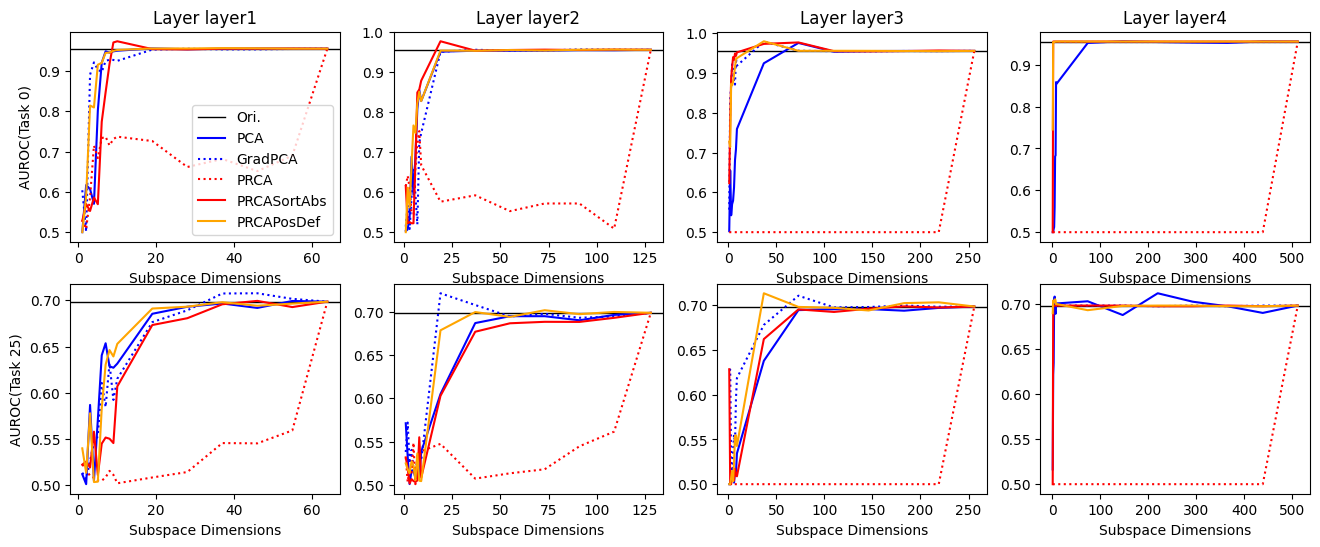

In [52]:
def viz_results(df):
    def mapping_ls_color(basis_class):
        return {
            PCA: ("-", "blue"),
            GradPCA: (":", "blue"),
            PRCA: (":", "red"),
            PRCASortAbs: ("-", "red"),
            PRCAPosDef: ("-", "orange")
        }[basis_class]
        # .get(basis_name, (None, None))
        
    arr_basis_classes = [
        PCA,
        GradPCA,
        PRCA,
        PRCASortAbs,
        PRCAPosDef,
    ]
    
    arr_task_id = sorted(df.task_id.unique())
    arr_layer = sorted(df.layer.unique())
    ncols = len(arr_layer)
    nrows = len(arr_task_id)

    plt.figure(figsize=(4*ncols, 3*nrows))
    for tix, task_id in enumerate(arr_task_id):
        for lix, layer in enumerate(arr_layer):
            plt.subplot(nrows, ncols, tix * ncols + lix + 1)
            if tix == 0:
                plt.title(f"Layer {layer}")
            plt.xlabel("Subspace Dimensions")
            
            for bix, basis_class in enumerate(arr_basis_classes):
                basis_name = basis_class.__name__
                
                _df = df[
                    (df.basis_name == basis_name) \
                        & (df.task_id == task_id) \
                        & (df.layer == layer)
                ]
                if bix == 0:
                    # assume that we always estimate perf @ k=d
                    ref_value = _df["val_auroc"].values[-1]
                    
                    plt.axhline(
                        ref_value,
                        color="k",
                        lw=1,
                        label="Ori."
                    )
                ls, color = mapping_ls_color(basis_class)
                plt.plot(
                    _df.k,
                    _df["val_auroc"],
                    label=basis_name,
                    ls=ls,
                    color=color
                )
        
            if lix == 0:
                plt.ylabel(f"AUROC(Task {task_id})")
                if tix == 0:
                    plt.legend()
viz_results(df_stats)

In [50]:
print(f"finished at {datetime.now()}")

finished at 2025-02-06 13:57:18.466716
